## Projected Tikhonov: Error vs. Rank $k$

In this notebook, I test out the error achieved when considering the projected problem
$$
\min_x \| K^+ K x - K^+ \tilde y \|_{M_\partial}^2 + \lambda^2 \| W x \|_M^2,
$$
where $\tilde y = y + \epsilon$, $y = K x$, $\tfrac{\| \epsilon \|}{\|y \|} = \delta$, for increasing target rank $k$. I also compare against a plain truncated SVD approach. From notebook `07_discrepancy_principle.ipynb`, I use $\nu_{dp} = 5$ to choose $\lambda_{dp}$. 

---

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from fenics import Function, plot

from utils.metrics import error3
from utils.utils import progress_bar, disk_cache
from utils.problem_setup import TestProblemsSetup
from utils.solvers import fast_proj_solver
from utils.exact_forward_operator import ExactForwardOperator, fast_get_weights
from utils.projected_tikhonov import get_epsilon, discrepancy_principle
from algorithms.rsvd_solvers import MatrixFreeRSVD

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

RESULTS_FOLDER = '../../results/transformed_tikhonov'
SEED = 15

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
def get_y_tilde(y, delta, seed):
    epsilon = get_epsilon(y, delta, seed)
    norm_epsilon = np.linalg.norm(epsilon)
    y_tilde = y + epsilon
    return y_tilde, norm_epsilon


@disk_cache(RESULTS_FOLDER)
def experiment(
        k_range: np.array,
        repeat: int = 1,
        delta: float = 0.01,
        nu: float = 10,
        pid: str = 'I',
        n: int = 64
    ) -> pd.DataFrame:
    """Experiment: rSVD and tSVD on noisy test problems."""
    pb = TestProblemsSetup(n).get_single_problem(pid)
    rsvd = MatrixFreeRSVD(pb['V_h'])

    # Compute full SVD once and corresponding weights
    exact = ExactForwardOperator(pb['V_h'])
    Uf, Sf, Vtf = np.linalg.svd(exact.K, full_matrices=False)

    results = []
    n_steps, step = repeat * len(k_range), 1
    for r in range(repeat):
        y_tilde, norm_epsilon = get_y_tilde(pb['y'], delta, seed=SEED + r)

        for k in k_range:
            progress_bar(step, n_steps, end_text=f' [{r=}, {k=}]')
            step += 1

            # Solve using rSVD
            U, S, Vt = rsvd.solve(k=k, seed=SEED + r + k)
            w = rsvd.weights()
            lam_dp_rsvd = discrepancy_principle(y_tilde, U, S, Vt.T, rsvd.M, w, norm_epsilon, nu)
            x_hat = rsvd.transformed_tikhonov_solve(y_tilde, w, lam_dp_rsvd)
            error_rsvd = {k + '_rsvd': v for k, v in error3(pb['x'], x_hat).items()}

            # Solve using tSVD
            U, S, Vt = Uf[:, :k], Sf[:k], Vtf[:k, :]
            w = fast_get_weights(S, Vt, exact.M_dx)
            lam_dp_svd = discrepancy_principle(y_tilde, U, S, Vt.T, exact.M_dx, w, norm_epsilon, nu)
            x_hat = fast_proj_solver(U, S, Vt.T, exact.M_dx, w, y_tilde, lambda_=lam_dp_svd)
            error_tsvd = {k + '_tsvd': v for k, v in error3(pb['x'], x_hat).items()}
            
            result = {'r': r, 'k': k, 'rsvd_lambda': lam_dp_rsvd, 'tsvd_lambda': lam_dp_svd}
            result.update(error_rsvd | error_tsvd)
            results.append(result)
        
    return pd.DataFrame(results)


def get_stats(df):
    cols = [c for c in df.columns if c not in ['k', 'rsvd_lambda', 'tsvd_lambda']]
    stats = df.groupby('k')[cols].agg(['mean', 'std'])  
    return stats


In [4]:
n = 64
nu = 10
repeat = 50
k_range = np.arange(5, 105, 5)

params = [
    {'k_range': k_range, 'repeat': repeat, 'n': n, 'nu': nu, 'pid': 'I'},
    {'k_range': k_range, 'repeat': repeat, 'n': n, 'nu': nu, 'pid': 'II'},
    {'k_range': k_range, 'repeat': repeat, 'n': n, 'nu': nu, 'pid': 'III'}
]
results = [{'params': p, 'df': experiment(**p)} for p in params]
stats = [{'params': r['params'], 'df': get_stats(r['df'])} for r in results]

../../figures/noisy_problem_I.png already exists


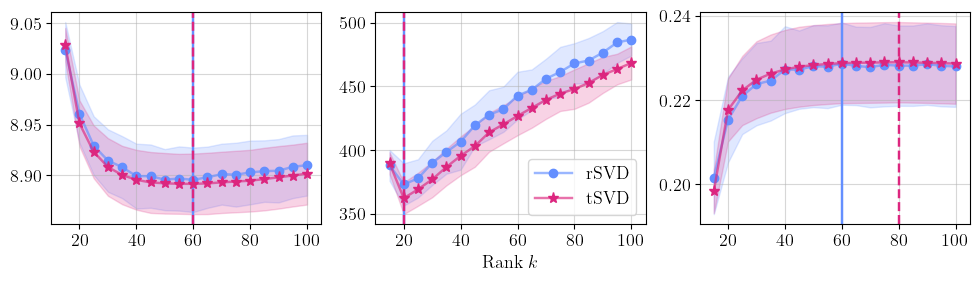

../../figures/noisy_problem_II.png already exists


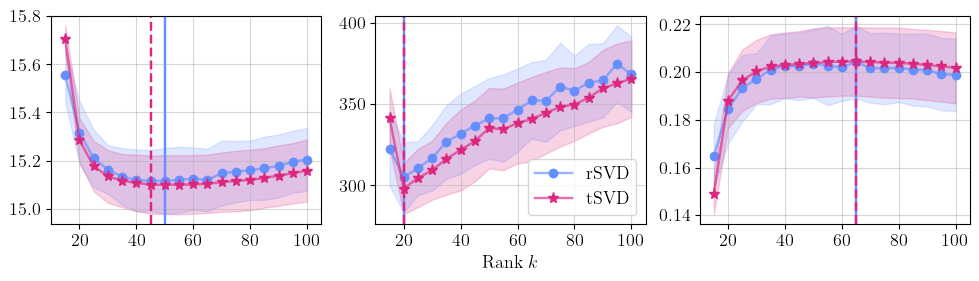

../../figures/noisy_problem_III.png already exists


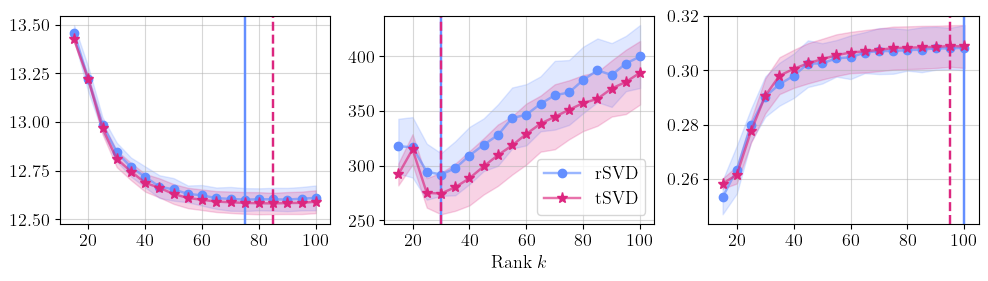

In [5]:
def plot_stats(stats, fig_name=None, k_min=0):
    from matplotlib.lines import Line2D
    from utils.colors import C2, M, MS, LS
    from utils.plotting import save_plot
    from matplotlib.ticker import MaxNLocator

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    for ax, me in zip(axes, ['euclidean', 'emd', 'auc_iou']):
        for i, method in enumerate(['rsvd', 'tsvd']):
            metric = me + '_' + method
            stats = stats[stats.index > k_min]  # limit k range
            mean   = stats[(metric, 'mean')]
            std    = stats[(metric, 'std')]
            k_vals = stats.index

            ax.plot(k_vals, mean.values, c=C2[i], lw=1.75, alpha=0.65)
            ax.plot(k_vals, mean.values, M[i], c=C2[i], ms=MS[i])
            ax.fill_between(k_vals, mean - std, mean + std, color=C2[i], alpha=0.2)
            

            # Mark optimal values
            if me == 'auc_iou': idx = np.argmax(mean.values)
            else: idx = np.argmin(mean.values)
            k_opt, e_opt = k_vals[idx], mean.values[idx]
            ax.axvline(k_opt, c=C2[i], ls=LS[i], lw=1.75, label=f'min')
            ax.set_xlim(min(k_vals) - 5, max(k_vals) + 5) 

        ax.xaxis.set_major_locator(MaxNLocator(6)) 
        ax.grid(True, alpha=0.5)
    
    # Custom labels
    handles, labels = [], ['rSVD', 'tSVD']
    for i in range(2):
        legend_line = Line2D([0], [0], color=C2[i], linewidth=1.75, alpha=.65)
        legend_marker = Line2D([0], [0], color=C2[i], marker=M[i], markersize=MS[i], linestyle='None')
        handles.append((legend_line, legend_marker))

    axes[1].legend(handles=handles, labels=labels)
    axes[1].set_xlabel('Rank $k$')
    plt.tight_layout()
    fig.subplots_adjust(wspace=0.2)
    save_plot(fig_name)
    plt.show()


for s in stats:
    params = s['params']
    df = s['df']
    name = f"noisy_problem_{params['pid']}"
    plot_stats(df, fig_name=name, k_min=10)

In [6]:
for s in stats:
    df = s['df']
    params = s['params']
    pid = params['pid']
    print(f'{pid:-^25}')
    for method in ['rsvd', 'tsvd']:
        row = ' & ' + method[0] + method[1:].upper()
        for dist in ['euclidean', 'emd', 'auc_iou']:
            mean = df[(f'{dist}_{method}', 'mean')]

            if dist != 'auc_iou': idx = np.argmin(mean)
            else: idx = np.argmax(mean)

            k_opt = mean.index[idx]
            row += f' & {k_opt}'
        print(row + ' \\\\')

------------I------------
 & rSVD & 60 & 20 & 60 \\
 & tSVD & 60 & 20 & 80 \\
-----------II------------
 & rSVD & 50 & 20 & 65 \\
 & tSVD & 45 & 20 & 65 \\
-----------III-----------
 & rSVD & 75 & 30 & 100 \\
 & tSVD & 85 & 30 & 95 \\


In [7]:
for s in stats:
    df = s['df']
    params = s['params']
    pid = params['pid']
    print(f'{pid:-^25}')

    for dist in ['euclidean', 'emd', 'auc_iou']:
        opt = np.max if dist == 'auc_iou' else np.min
        mean_rsvd_opt = opt(df[(f'{dist}_rsvd', 'mean')])
        mean_tsvd_opt = opt(df[(f'{dist}_tsvd', 'mean')])
        diff = -100 * (mean_tsvd_opt - mean_rsvd_opt) / mean_tsvd_opt
        diff = np.round(diff, 2)
        print(dist, diff)


------------I------------
euclidean 0.04
emd 2.99
auc_iou -0.14
-----------II------------
euclidean 0.11
emd 2.35
auc_iou -0.09
-----------III-----------
euclidean 0.16
emd 6.33
auc_iou -0.21


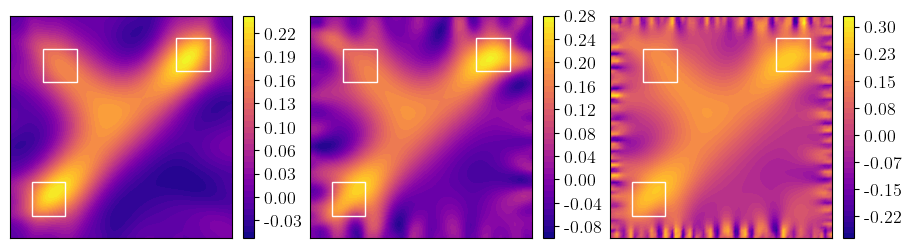

In [11]:
lam_dp = 0.215443  # lambda found in experiment

pb = TestProblemsSetup(n=64).get_single_problem('II')
params = TestProblemsSetup(n=64).problem_params['II']

rsvd = MatrixFreeRSVD(pb['V_h'])
y, _ = get_y_tilde(pb['y'], delta=0.01, seed=SEED)


f_list = []
for k in [20, 50, 150]:
    rsvd.solve(k)
    x_hat = rsvd.transformed_tikhonov_solve(y, rsvd.weights(), lam=lam_dp)
    
    f = Function(pb['V_h'])
    f.vector()[:] = x_hat

    f_list.append(f)


def plot_multiple_f(f_list, params, names=None, fig_name=None, shrink=0.3):
    from utils.colors import CMAP
    from utils.plotting import save_plot
    import matplotlib.patches as patches

    width = params['width']
    height = params['height']
    x0s, y0s = params['x0'], params['y0']

    fig, axes = plt.subplots(1, 3, figsize=(9, 6.06), constrained_layout=True)

    if names is None:
        names = ['' for _ in axes.flat]

    for ax, func, name in zip(axes.flat, f_list, names):
        plt.sca(ax)
        #vmin = np.min(func.vector().get_local())

        p = plot(func, title=name, cmap=CMAP)
        fig.colorbar(p, ax=ax, format="%.2f", shrink=shrink)
        ax.set_xticks([])
        ax.set_yticks([])

        for x0, y0 in zip(x0s, y0s):
            square = patches.Rectangle(
                (x0, y0), width, height,
                edgecolor="white",
                facecolor="none"
            )
            ax.add_patch(square)

    save_plot(fig_name=fig_name)
    plt.show()


plot_multiple_f(f_list, params, shrink=0.372, fig_name='reconstruction_noisy_problem')

In [9]:
exact = ExactForwardOperator(pb['V_h'])
U, S, Vt = np.linalg.svd(exact.assemble_K(), full_matrices=False)

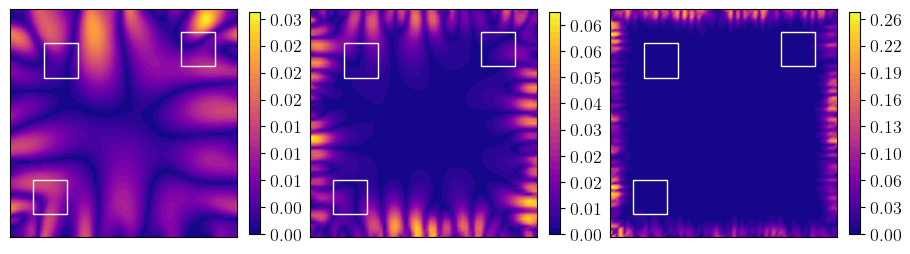

In [10]:
lam_dp = 0.215443


f_list2 = []
i = 0
for k in [20, 60, 150]:
    Uk, Sk, Vkt = U[:, :k], S[:k], Vt[:k, :]
    w = fast_get_weights(Sk, Vkt, exact.M_dx)
    x_hat = fast_proj_solver(Uk, Sk, Vkt.T, exact.M_dx, w, y, lambda_=lam_dp)
    
    x_hat0 = f_list[i].vector().get_local(); i += 1

    f = Function(pb['V_h'])
    f.vector()[:] = np.abs(x_hat - x_hat0)

    f_list2.append(f)


plot_multiple_f(f_list2, params, shrink=0.372, fig_name=None)